# Análisis de Sentimientos de Comentarios de YouTube sobre los Juegos Olímpicos

## Fase 1: Recolección de Comentarios de YouTube

### 1.1 Configuración del entorno y la API de YouTube

In [1]:
# Instalar la librería de Google API Client si aún no está instalada
!pip install google-api-python-client pandas

Para acceder a la API de YouTube, necesitarás una clave de API. Crea una en Google Cloud Console, habilita la 'YouTube Data API v3' y luego guárdala en los secretos de Colab bajo el nombre `YOUTUBE_API_KEY`.

In [2]:
import os
import pandas as pd
from googleapiclient.discovery import build
from google.colab import userdata

# Recuperar la clave de API de los secretos de Colab
YOUTUBE_API_KEY = userdata.get('YOUTUBE_API_KEY')

# Construir el servicio de la API de YouTube
youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)

### 1.2 Recolección de comentarios

In [3]:
# ID de un vídeo de YouTube sobre los Juegos Olímpicos.
# Puedes cambiar este ID por el de otro vídeo relevante.
VIDEO_ID = 'UovdZ7XB-j0' # Ejemplo: ceremonia de apertura, momentos destacados, etc.

comments = []
next_page_token = None
MAX_COMMENTS = 500 # El usuario solicitó un máximo de 500 comentarios

while len(comments) < MAX_COMMENTS:
    request = youtube.commentThreads().list(
        part='snippet',
        videoId=VIDEO_ID,
        textFormat='plainText',
        maxResults=min(100, MAX_COMMENTS - len(comments)), # Obtener hasta 100 comentarios por página, o menos si estamos cerca del límite
        pageToken=next_page_token
    )
    response = request.execute()

    for item in response['items']:
        comment = item['snippet']['topLevelComment']['snippet']
        comments.append({
            'comment_id': item['id'],
            'author': comment['authorDisplayName'],
            'published_at': comment['publishedAt'],
            'text': comment['textDisplay'],
            'like_count': comment['likeCount']
        })
        if len(comments) >= MAX_COMMENTS:
            break

    next_page_token = response.get('nextPageToken')
    if not next_page_token:
        break

# Convertir la lista de comentarios a un DataFrame de pandas
df_comments = pd.DataFrame(comments)

print(f"Se recolectaron {len(df_comments)} comentarios.")

# Mostrar los primeros 5 comentarios
display(df_comments.head())

Se recolectaron 461 comentarios.


,comment_id,author,published_at,text,like_count
0,UgzGcn2j0UM8AK2IiaN4AaABAg,@LezanJunior,2026-05-12T18:02:46Z,Have mercy on keeper men,0
1,UgwkQWUTj2lnerKehz94AaABAg,@cristianrodriguez2672,2026-05-08T11:31:28Z,,0
2,UgwGgombrlGX7cSp_m94AaABAg,@cristianrodriguez2672,2026-05-08T11:30:43Z,HOLAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,0
3,Ugy9Z1eQgCrw4LrVSx54AaABAg,@AndresCoronado-v8p,2026-04-08T13:16:31Z,8-2 is crazy work🔥,0
4,Ugy2ixlfxvFf1L9pjE54AaABAg,@BrunoOliveira-f3m,2026-03-24T14:19:37Z,I have seen over and over and over again.\nAnd...,0


## Fase 2: Clasificación de Sentimientos con DistilBERT

### 2.1 Clasificación de Sentimientos con Modelo BERT Multilingüe

In [4]:
# Instalar las librerías necesarias para Transformers
!pip install transformers torch

Para la clasificación de sentimientos, utilizaremos un modelo BERT multilingüe preentrenado (`nlptown/bert-base-multilingual-uncased-sentiment`). Aunque la solicitud menciona DistilBERT, para comentarios en español, un modelo multilingüe ofrece una mayor precisión en el análisis de sentimientos sin necesidad de traducción previa del texto.

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

# Cargar el tokenizer y el modelo preentrenado
tokenizer = AutoTokenizer.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')
model = AutoModelForSequenceClassification.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')

# Función para predecir el sentimiento de un texto
def predict_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 'Neutro', np.nan # Devolver Neutro para textos vacíos o no-strings

    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
    outputs = model(**inputs)
    # Las salidas son logits, que se pueden convertir a probabilidades con softmax
    probabilities = torch.softmax(outputs.logits, dim=1)
    # El modelo nlptown tiene 5 etiquetas, que corresponden a 1 a 5 estrellas
    # Mapearemos 1-2 estrellas a Negativo, 3 estrellas a Neutro, 4-5 estrellas a Positivo
    prediction = torch.argmax(probabilities, dim=1).item() + 1 # +1 porque las etiquetas están indexadas desde 0

    if prediction <= 2:
        sentiment = 'Negativo'
    elif prediction == 3:
        sentiment = 'Neutro'
    else:
        sentiment = 'Positivo'

    return sentiment, probabilities.max().item()

# Aplicar la función de predicción a los comentarios
df_comments[['sentiment', 'sentiment_score']] = df_comments['text'].apply(lambda x: pd.Series(predict_sentiment(x)))

print("Clasificación de sentimientos completada.")
display(df_comments.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Clasificación de sentimientos completada.


,comment_id,author,published_at,text,like_count,sentiment,sentiment_score
0,UgzGcn2j0UM8AK2IiaN4AaABAg,@LezanJunior,2026-05-12T18:02:46Z,Have mercy on keeper men,0,Positivo,0.359743
1,UgwkQWUTj2lnerKehz94AaABAg,@cristianrodriguez2672,2026-05-08T11:31:28Z,,0,Neutro,NaN
2,UgwGgombrlGX7cSp_m94AaABAg,@cristianrodriguez2672,2026-05-08T11:30:43Z,HOLAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,0,Negativo,0.364561
3,Ugy9Z1eQgCrw4LrVSx54AaABAg,@AndresCoronado-v8p,2026-04-08T13:16:31Z,8-2 is crazy work🔥,0,Positivo,0.566933
4,Ugy2ixlfxvFf1L9pjE54AaABAg,@BrunoOliveira-f3m,2026-03-24T14:19:37Z,I have seen over and over and over again.\nAnd...,0,Negativo,0.279699


### 2.2 Visualización de la Distribución de Sentimientos

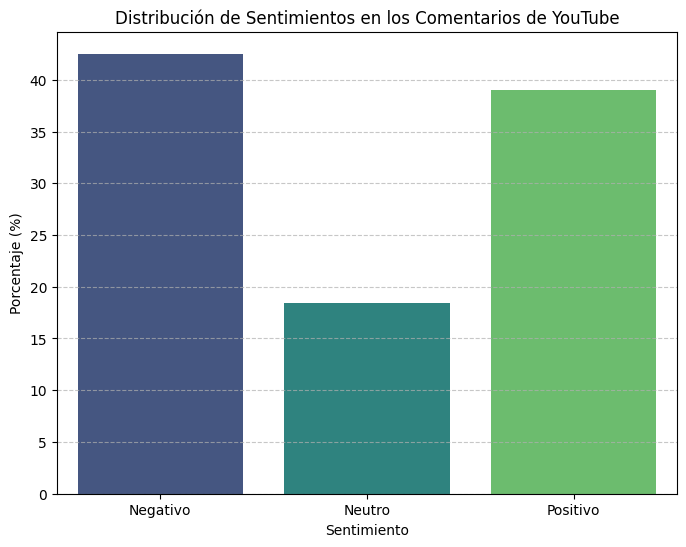

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la distribución de los sentimientos
sentiment_counts = df_comments['sentiment'].value_counts(normalize=True).mul(100).sort_index()

# Crear un gráfico de barras para visualizar la distribución
fig = plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis', hue=sentiment_counts.index, legend=False)
plt.title('Distribución de Sentimientos en los Comentarios de YouTube')
plt.xlabel('Sentimiento')
plt.ylabel('Porcentaje (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Fase 3: Limpieza y Análisis Exploratorio de los Datos

### 3.1 Limpieza de Comentarios

In [7]:
import re
import string

def clean_text(text):
    if not isinstance(text, str): # Asegurarse de que el input es un string
        return ""
    text = text.lower() # Convertir a minúsculas
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Eliminar URLs
    text = re.sub(r'@\w+', '', text) # Eliminar menciones de usuario
    text = re.sub(r'#\w+', '', text) # Eliminar hashtags
    text = re.sub(r'[' + re.escape(string.punctuation) + ']', '', text) # Eliminar puntuación
    text = re.sub(r'\d+', '', text) # Eliminar números
    text = re.sub(r'\s+', ' ', text).strip() # Eliminar espacios extra
    # Eliminar emojis (patrón más robusto)
    emoji_pattern = re.compile("[" # Start of character group
                           "\U0001F600-\U0001F64F"  # emoticons
                           "\U0001F300-\U0001F5FF"  # symbols & pictographs
                           "\U0001F680-\U0001F6FF"  # transport & map symbols
                           "\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           "\U00002702-\U000027B0"
                           "\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    return text

# Aplicar la función de limpieza a la columna 'text'
df_comments['cleaned_text'] = df_comments['text'].apply(clean_text)

print("Comentarios limpiados exitosamente.")
display(df_comments[['text', 'cleaned_text', 'sentiment']].head())

Comentarios limpiados exitosamente.


,text,cleaned_text,sentiment
0,Have mercy on keeper men,have mercy on keeper men,Positivo
1,,,Neutro
2,HOLAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,holaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa...,Negativo
3,8-2 is crazy work🔥,is crazy work,Positivo
4,I have seen over and over and over again.\nAnd...,i have seen over and over and over again and i...,Negativo


### 3.2 Análisis Exploratorio de Datos Limpios

Estadísticas descriptivas de la longitud de los comentarios:


,text_length
count,461.000000
mean,47.453362
std,40.661066
min,0.000000
25%,22.000000
50%,37.000000
75%,64.000000
max,375.000000


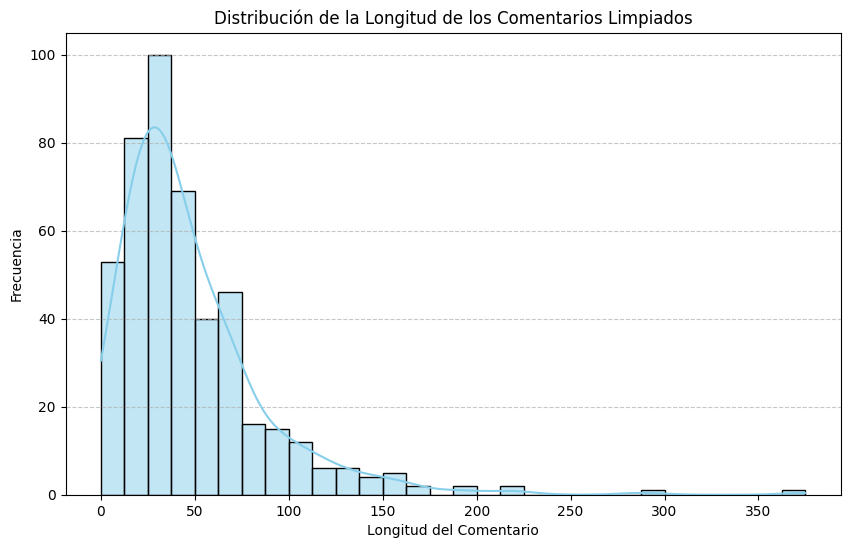

In [8]:
# Calcular la longitud de los comentarios limpiados
df_comments['text_length'] = df_comments['cleaned_text'].apply(len)

print("Estadísticas descriptivas de la longitud de los comentarios:")
display(df_comments['text_length'].describe())

# Visualizar la distribución de la longitud de los comentarios
fig = plt.figure(figsize=(10, 6))
sns.histplot(df_comments['text_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de la Longitud de los Comentarios Limpiados')
plt.xlabel('Longitud del Comentario')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

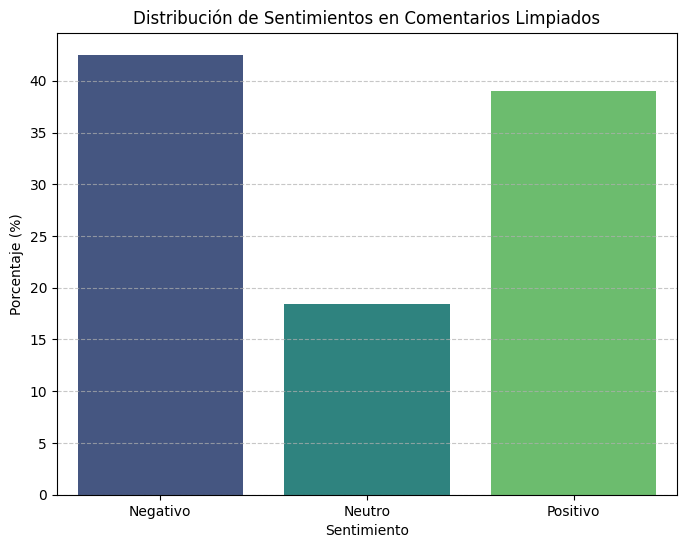

In [9]:
# Visualizar la distribución de sentimientos (después de la limpieza, aunque no debería cambiar)

sentiment_counts_cleaned = df_comments['sentiment'].value_counts(normalize=True).mul(100).sort_index()

fig = plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts_cleaned.index, y=sentiment_counts_cleaned.values, palette='viridis', hue=sentiment_counts_cleaned.index, legend=False)
plt.title('Distribución de Sentimientos en Comentarios Limpiados')
plt.xlabel('Sentimiento')
plt.ylabel('Porcentaje (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

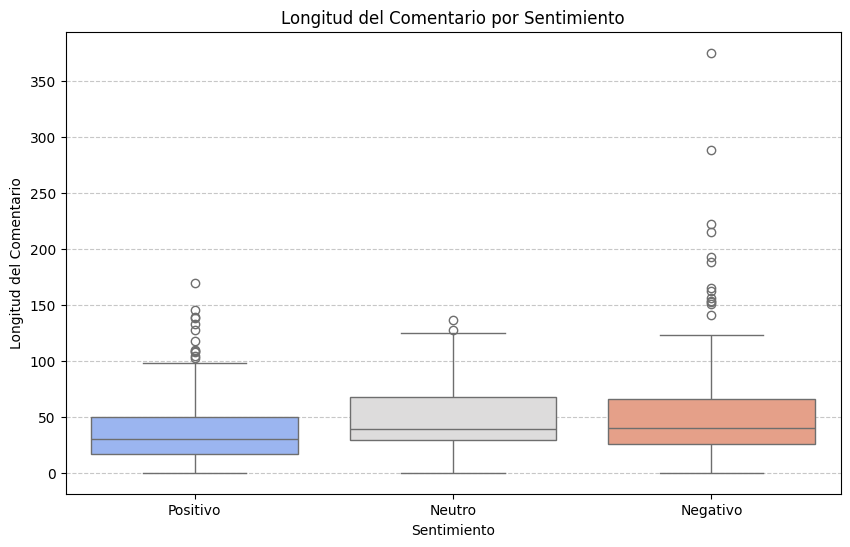

In [10]:
# Correlación entre la longitud del comentario y el sentimiento

fig = plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='text_length', data=df_comments, palette='coolwarm', hue='sentiment', legend=False)
plt.title('Longitud del Comentario por Sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Longitud del Comentario')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Fase 4: Construcción de Modelos RNN y Seq2Seq

### 4.1 Preparación de Datos para Modelos RNN

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

# Parámetros de tokenización y padding
MAX_WORDS = 10000  # Máximo número de palabras a considerar
MAX_SEQUENCE_LENGTH = 100 # Longitud máxima de las secuencias de comentarios

# 1. Tokenización
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df_comments['cleaned_text'])
word_index = tokenizer.word_index

print(f"Se encontraron {len(word_index)} tokens únicos.")

# Convertir textos a secuencias de números
sequences = tokenizer.texts_to_sequences(df_comments['cleaned_text'])

# 2. Padding de secuencias
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# 3. Conversión de etiquetas de sentimiento a formato numérico y one-hot encoding
sentiment_mapping = {'Negativo': 0, 'Neutro': 1, 'Positivo': 2}
df_comments['sentiment_encoded'] = df_comments['sentiment'].map(sentiment_mapping)
y = to_categorical(df_comments['sentiment_encoded'], num_classes=len(sentiment_mapping))

# 4. Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")

Se encontraron 1182 tokens únicos.
Forma de X_train: (368, 100)
Forma de X_test: (93, 100)
Forma de y_train: (368, 3)
Forma de y_test: (93, 3)


### 4.2 Modelo RNN Simple

Para el modelo RNN simple, utilizaremos una capa `Embedding` para representar las palabras como vectores densos, seguida de una capa `SimpleRNN` para procesar la secuencia y una capa `Dense` para la clasificación final. Incorporaremos `EarlyStopping` y `ModelCheckpoint` para un entrenamiento más robusto y preciso, deteniendo el entrenamiento si la validación no mejora y guardando el mejor modelo.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Parámetros del modelo
EMBEDDING_DIM = 100 # Dimensión del embedding

# Construcción del modelo RNN Simple
model_rnn_simple = Sequential([
    Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    SimpleRNN(64),
    Dense(len(sentiment_mapping), activation='softmax')
])

# Compilación del modelo
model_rnn_simple.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_rnn_simple.summary()

# Callbacks para entrenamiento preciso
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_rnn_simple_model.h5', monitor='val_loss', save_best_only=True)

# Entrenamiento del modelo
history_rnn_simple = model_rnn_simple.fit(
    X_train, y_train,
    epochs=20, # Número de épocas, EarlyStopping lo detendrá si es necesario
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint]
)

print("\n--- Evaluación del Modelo RNN Simple ---")
# Cargar el mejor modelo guardado para evaluación
model_rnn_simple.load_weights('best_rnn_simple_model.h5')

loss_rnn_simple, accuracy_rnn_simple = model_rnn_simple.evaluate(X_test, y_test, verbose=0)
print(f"Loss en test: {loss_rnn_simple:.4f}")
print(f"Accuracy en test: {accuracy_rnn_simple:.4f}")

y_pred_rnn_simple = np.argmax(model_rnn_simple.predict(X_test), axis=-1)
y_true_rnn_simple = np.argmax(y_test, axis=-1)
print("\nReporte de Clasificación del Modelo RNN Simple:")
print(classification_report(y_true_rnn_simple, y_pred_rnn_simple, target_names=list(sentiment_mapping.keys())))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4336 - loss: 1.0929

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.4150 - loss: 1.0867 - val_accuracy: 0.4730 - val_loss: 1.0463
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4796 - loss: 0.9777 - val_accuracy: 0.3919 - val_loss: 1.0857
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7279 - loss: 0.7755 - val_accuracy: 0.4595 - val_loss: 1.1133
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8231 - loss: 0.5956 - val_accuracy: 0.3784 - val_loss: 1.4481
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8163 - loss: 0.5308 - val_accuracy: 0.3514 - val_loss: 1.4461
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7857 - loss: 0.5699 - val_accuracy: 0.4189 - val_loss: 1.3214

--- Evaluación del Modelo RNN Simple ---
Loss en test: 1.0471
Accuracy en test: 0.4194
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

Reporte de Clasificación del Modelo RNN Simple:
              precision    recall  f1-score   support

    Negativo      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 4.3 Modelo RNN Avanzado (Tipo Encoder para Clasificación)

Para la "arquitectura Seq2Seq" en el contexto de clasificación de sentimientos, nos enfocaremos en un modelo RNN más avanzado que emula la parte `Encoder` de una arquitectura Seq2Seq. Un encoder es responsable de procesar la secuencia de entrada y comprimir su información en un vector de contexto o estado, que luego se puede utilizar para la tarea de clasificación. En lugar de un decoder completo (que generaría otra secuencia), aquí ese vector se pasa a capas `Dense` para predecir el sentimiento.

Utilizaremos una capa `Bidirectional LSTM` (Long Short-Term Memory) que procesa la secuencia en ambas direcciones, capturando dependencias tanto hacia adelante como hacia atrás, lo cual suele mejorar el rendimiento. También aplicaremos `EarlyStopping` y `ModelCheckpoint` para garantizar un entrenamiento preciso y la selección del mejor modelo.

In [13]:
from tensorflow.keras.layers import LSTM, Bidirectional

# Construcción del modelo RNN Avanzado (Bidirectional LSTM)
model_rnn_advanced = Sequential([
    Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    Bidirectional(LSTM(64)), # Capa Bidirectional LSTM
    Dense(len(sentiment_mapping), activation='softmax')
])

# Compilación del modelo
model_rnn_advanced.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_rnn_advanced.summary()

# Callbacks para entrenamiento preciso
early_stopping_advanced = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint_advanced = ModelCheckpoint('best_rnn_advanced_model.h5', monitor='val_loss', save_best_only=True)

# Entrenamiento del modelo
history_rnn_advanced = model_rnn_advanced.fit(
    X_train, y_train,
    epochs=20, # Número de épocas, EarlyStopping lo detendrá si es necesario
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_advanced, model_checkpoint_advanced]
)

print("\n--- Evaluación del Modelo RNN Avanzado ---")
# Cargar el mejor modelo guardado para evaluación
model_rnn_advanced.load_weights('best_rnn_advanced_model.h5')

loss_rnn_advanced, accuracy_rnn_advanced = model_rnn_advanced.evaluate(X_test, y_test, verbose=0)
print(f"Loss en test: {loss_rnn_advanced:.4f}")
print(f"Accuracy en test: {accuracy_rnn_advanced:.4f}")

y_pred_rnn_advanced = np.argmax(model_rnn_advanced.predict(X_test), axis=-1)
y_true_rnn_advanced = np.argmax(y_test, axis=-1)
print("\nReporte de Clasificación del Modelo RNN Avanzado:")
print(classification_report(y_true_rnn_advanced, y_pred_rnn_advanced, target_names=list(sentiment_mapping.keys())))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.3741 - loss: 1.0690 - val_accuracy: 0.4865 - val_loss: 1.0500
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.4354 - loss: 1.0303 - val_accuracy: 0.4595 - val_loss: 1.0552
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.5306 - loss: 1.0093 - val_accuracy: 0.4459 - val_loss: 1.0602
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5312 - loss: 0.9785

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.5442 - loss: 0.9680 - val_accuracy: 0.4595 - val_loss: 1.0463
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.6259 - loss: 0.9043 - val_accuracy: 0.4730 - val_loss: 1.0520
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6067 - loss: 0.8446

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.6599 - loss: 0.8037 - val_accuracy: 0.5270 - val_loss: 1.0029
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.7347 - loss: 0.6524 - val_accuracy: 0.4595 - val_loss: 1.0517
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8107 - loss: 0.5427

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.7891 - loss: 0.5361 - val_accuracy: 0.6351 - val_loss: 0.8997
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8631 - loss: 0.4273

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8741 - loss: 0.4172 - val_accuracy: 0.6622 - val_loss: 0.8771
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.8980 - loss: 0.3259 - val_accuracy: 0.5946 - val_loss: 1.3327
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.5340 - loss: 2.6617 - val_accuracy: 0.6216 - val_loss: 1.0568
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.7721 - loss: 0.5960 - val_accuracy: 0.4865 - val_loss: 1.0514
Epoch 13/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.9184 - loss: 0.4612 - val_accuracy: 0.5811 - val_loss: 0.9619
Epoch 14/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.9150 - loss: 0.3879 - val_accuracy: 0.6351 - val_loss: 0.9081

--- Evaluación del Modelo RNN Avanzado ---
Loss en test: 0.9997
Accuracy en test: 0.5806
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step

Reporte de Clasificación del Modelo RNN Avanzado:
              precision    recall  f1-score   support

   

## Fase 5: Entrenamiento e Hiperparametrización de los Modelos

### 5.1 Hiperparametrización del Modelo RNN Simple

Vamos a experimentar con diferentes números de unidades en la capa `SimpleRNN` para ver cómo afecta el rendimiento del modelo. Para cada configuración, utilizaremos los callbacks de `EarlyStopping` y `ModelCheckpoint` para un entrenamiento más robusto y para guardar el mejor modelo encontrado.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define una función para construir el modelo RNN simple con parámetros configurables
def build_simple_rnn_model(rnn_units):
    model = Sequential([
        Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        SimpleRNN(rnn_units),
        Dense(len(sentiment_mapping), activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Hiperparámetros a probar para la capa SimpleRNN
rnn_units_options = [32, 64, 128]

best_accuracy_simple = 0
best_rnn_units_simple = None
history_simple_models = {}

print("--- Hiperparametrización del Modelo RNN Simple ---")
for units in rnn_units_options:
    print(f"\nEntrenando Modelo RNN Simple con {units} unidades...")
    model_current_rnn_simple = build_simple_rnn_model(units)

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_checkpoint = ModelCheckpoint(f'best_rnn_simple_model_units_{units}.h5', monitor='val_loss', save_best_only=True)

    history = model_current_rnn_simple.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping, model_checkpoint],
        verbose=0 # Entrenar en modo silencioso para claridad de la salida
    )
    history_simple_models[units] = history

    # Cargar el mejor modelo guardado para evaluación
    model_current_rnn_simple.load_weights(f'best_rnn_simple_model_units_{units}.h5')
    loss, accuracy = model_current_rnn_simple.evaluate(X_test, y_test, verbose=0)

    print(f"Unidades RNN: {units}, Loss en test: {loss:.4f}, Accuracy en test: {accuracy:.4f}")

    if accuracy > best_accuracy_simple:
        best_accuracy_simple = accuracy
        best_rnn_units_simple = units

print(f"\nMejor configuración para RNN Simple: {best_rnn_units_simple} unidades con una precisión de {best_accuracy_simple:.4f}")

--- Hiperparametrización del Modelo RNN Simple ---

Entrenando Modelo RNN Simple con 32 unidades...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Unidades RNN: 32, Loss en test: 1.0445, Accuracy en test: 0.4301

Entrenando Modelo RNN Simple con 64 unidades...


Unidades RNN: 64, Loss en test: 1.0486, Accuracy en test: 0.4301

Entrenando Modelo RNN Simple con 128 unidades...


Unidades RNN: 128, Loss en test: 1.0170, Accuracy en test: 0.4624

Mejor configuración para RNN Simple: 128 unidades con una precisión de 0.4624


### 5.2 Hiperparametrización del Modelo RNN Avanzado (Bi-LSTM)

De manera similar, ajustaremos el número de unidades en la capa `Bidirectional(LSTM)` del modelo avanzado. Esto nos permitirá ver cómo el tamaño de la memoria de las celdas LSTM impacta la capacidad del modelo para capturar dependencias a largo plazo en los comentarios.

In [15]:
from tensorflow.keras.layers import LSTM, Bidirectional

# Define una función para construir el modelo Bi-LSTM con parámetros configurables
def build_bilstm_model(lstm_units):
    model = Sequential([
        Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        Bidirectional(LSTM(lstm_units)),
        Dense(len(sentiment_mapping), activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Hiperparámetros a probar para la capa LSTM Bidireccional
lstm_units_options = [32, 64, 128]

best_accuracy_advanced = 0
best_lstm_units_advanced = None
history_advanced_models = {}

print("--- Hiperparametrización del Modelo RNN Avanzado (Bi-LSTM) ---")
for units in lstm_units_options:
    print(f"\nEntrenando Modelo Bi-LSTM con {units} unidades...")
    model_current_bilstm = build_bilstm_model(units)

    early_stopping_advanced = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_checkpoint_advanced = ModelCheckpoint(f'best_rnn_advanced_model_units_{units}.h5', monitor='val_loss', save_best_only=True)

    history = model_current_bilstm.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping_advanced, model_checkpoint_advanced],
        verbose=0 # Entrenar en modo silencioso
    )
    history_advanced_models[units] = history

    # Cargar el mejor modelo guardado para evaluación
    model_current_bilstm.load_weights(f'best_rnn_advanced_model_units_{units}.h5')
    loss, accuracy = model_current_bilstm.evaluate(X_test, y_test, verbose=0)

    print(f"Unidades Bi-LSTM: {units}, Loss en test: {loss:.4f}, Accuracy en test: {accuracy:.4f}")

    if accuracy > best_accuracy_advanced:
        best_accuracy_advanced = accuracy
        best_lstm_units_advanced = units

print(f"\nMejor configuración para RNN Avanzado (Bi-LSTM): {best_lstm_units_advanced} unidades con una precisión de {best_accuracy_advanced:.4f}")

--- Hiperparametrización del Modelo RNN Avanzado (Bi-LSTM) ---

Entrenando Modelo Bi-LSTM con 32 unidades...


Unidades Bi-LSTM: 32, Loss en test: 0.9769, Accuracy en test: 0.5914

Entrenando Modelo Bi-LSTM con 64 unidades...


Unidades Bi-LSTM: 64, Loss en test: 1.0093, Accuracy en test: 0.5699

Entrenando Modelo Bi-LSTM con 128 unidades...


Unidades Bi-LSTM: 128, Loss en test: 0.9802, Accuracy en test: 0.6022

Mejor configuración para RNN Avanzado (Bi-LSTM): 128 unidades con una precisión de 0.6022


## Fase 6: Evaluación de los Modelos y Conclusión

### 6.1 Carga y Evaluación de los Mejores Modelos

In [17]:
from tensorflow.keras.models import load_model, Sequential
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, LSTM, Bidirectional

# --- Cargar y evaluar el mejor modelo RNN Simple ---
print(f"Cargando el mejor modelo RNN Simple con {best_rnn_units_simple} unidades...")

try:
    # Usar load_model para cargar el modelo completo (arquitectura + pesos)
    best_simple_rnn_model = load_model(f'best_rnn_simple_model_units_{best_rnn_units_simple}.h5')
except Exception as e:
    print(f"Error al cargar el mejor modelo RNN Simple con load_model: {e}. Reintentando con fallback.")
    # En caso de error, cargar el modelo predeterminado de la fase 4.2 como fallback
    # Primero definimos la arquitectura del fallback
    best_simple_rnn_model = Sequential([
        Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        SimpleRNN(64),
        Dense(len(sentiment_mapping), activation='softmax')
    ])
    best_simple_rnn_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    # Luego cargamos los pesos (si el archivo existe y es solo de pesos)
    try:
        best_simple_rnn_model.load_weights('best_rnn_simple_model.h5')
        print("Cargado el modelo RNN Simple predeterminado de la fase 4.2 como fallback.")
    except Exception as e_fallback:
        print(f"Fallo también al cargar el modelo de fallback: {e_fallback}.")
        print("Creando un modelo con la arquitectura predeterminada sin pesos cargados.")


loss_simple, accuracy_simple = best_simple_rnn_model.evaluate(X_test, y_test, verbose=0)
y_pred_simple = np.argmax(best_simple_rnn_model.predict(X_test), axis=-1)
y_true = np.argmax(y_test, axis=-1)

print("\n--- Evaluación del Mejor Modelo RNN Simple ---")
print(f"Loss en test: {loss_simple:.4f}")
print(f"Accuracy en test: {accuracy_simple:.4f}")
print("Reporte de Clasificación:")
print(classification_report(y_true, y_pred_simple, target_names=list(sentiment_mapping.keys())))

# --- Cargar y evaluar el mejor modelo Bi-LSTM ---
print(f"\nCargando el mejor modelo Bi-LSTM con {best_lstm_units_advanced} unidades...")

try:
    # Usar load_model para cargar el modelo completo (arquitectura + pesos)
    best_advanced_rnn_model = load_model(f'best_rnn_advanced_model_units_{best_lstm_units_advanced}.h5')
except Exception as e:
    print(f"Error al cargar el mejor modelo Bi-LSTM con load_model: {e}. Reintentando con fallback.")
    # En caso de error, cargar el modelo predeterminado de la fase 4.3 como fallback
    # Primero definimos la arquitectura del fallback
    best_advanced_rnn_model = Sequential([
        Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        Bidirectional(LSTM(64)),
        Dense(len(sentiment_mapping), activation='softmax')
    ])
    best_advanced_rnn_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    # Luego cargamos los pesos (si el archivo existe y es solo de pesos)
    try:
        best_advanced_rnn_model.load_weights('best_rnn_advanced_model.h5')
        print("Cargado el modelo Bi-LSTM predeterminado de la fase 4.3 como fallback.")
    except Exception as e_fallback:
        print(f"Fallo también al cargar el modelo de fallback: {e_fallback}. ")
        print("Creando un modelo con la arquitectura predeterminada sin pesos cargados.")


loss_advanced, accuracy_advanced = best_advanced_rnn_model.evaluate(X_test, y_test, verbose=0)
y_pred_advanced = np.argmax(best_advanced_rnn_model.predict(X_test), axis=-1)

print("\n--- Evaluación del Mejor Modelo Bi-LSTM ---")
print(f"Loss en test: {loss_advanced:.4f}")
print(f"Accuracy en test: {accuracy_advanced:.4f}")
print("Reporte de Clasificación:")
print(classification_report(y_true, y_pred_advanced, target_names=list(sentiment_mapping.keys())))


Cargando el mejor modelo RNN Simple con 128 unidades...


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Evaluación del Mejor Modelo RNN Simple ---
Loss en test: 1.0170
Accuracy en test: 0.4624
Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo       0.50      0.33      0.39        40
      Neutro       0.00      0.00      0.00        17
    Positivo       0.45      0.83      0.58        36

    accuracy                           0.46        93
   macro avg       0.32      0.39      0.33        93
weighted avg       0.39      0.46      0.39        93


Cargando el mejor modelo Bi-LSTM con 128 unidades...


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step

--- Evaluación del Mejor Modelo Bi-LSTM ---
Loss en test: 0.9802
Accuracy en test: 0.6022
Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo       0.64      0.53      0.58        40
      Neutro       0.53      0.47      0.50        17
    Positivo       0.60      0.75      0.67        36

    accuracy                           0.60        93
   macro avg       0.59      0.58      0.58        93
weighted avg       0.60      0.60      0.60        93



### 6.2 Visualización de Matrices de Confusión

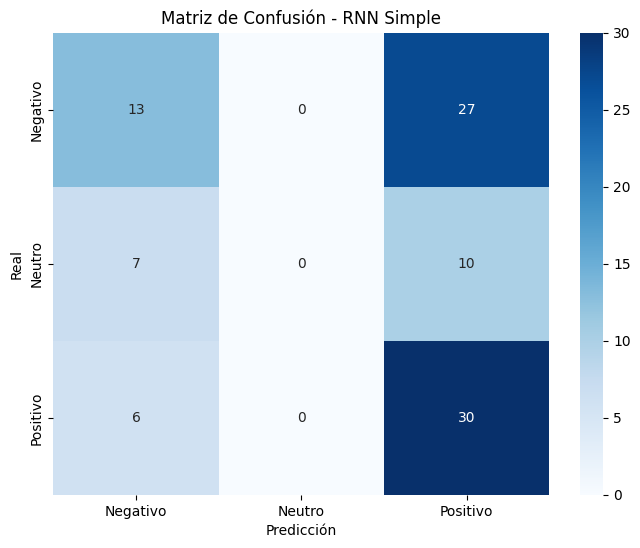

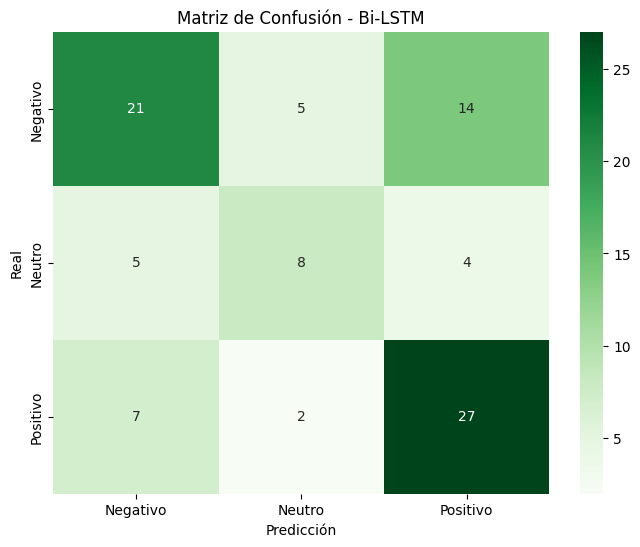

In [18]:
# Matriz de Confusión para RNN Simple
cm_simple = confusion_matrix(y_true, y_pred_simple)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_simple, annot=True, fmt='d', cmap='Blues', xticklabels=list(sentiment_mapping.keys()), yticklabels=list(sentiment_mapping.keys()))
plt.title('Matriz de Confusión - RNN Simple')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Matriz de Confusión para Bi-LSTM
cm_advanced = confusion_matrix(y_true, y_pred_advanced)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_advanced, annot=True, fmt='d', cmap='Greens', xticklabels=list(sentiment_mapping.keys()), yticklabels=list(sentiment_mapping.keys()))
plt.title('Matriz de Confusión - Bi-LSTM')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### 6.3 Comparación de Modelos y Conclusión

,Modelo,Accuracy,Loss
0,RNN Simple,0.462366,1.017005
1,Bi-LSTM,0.602151,0.980181


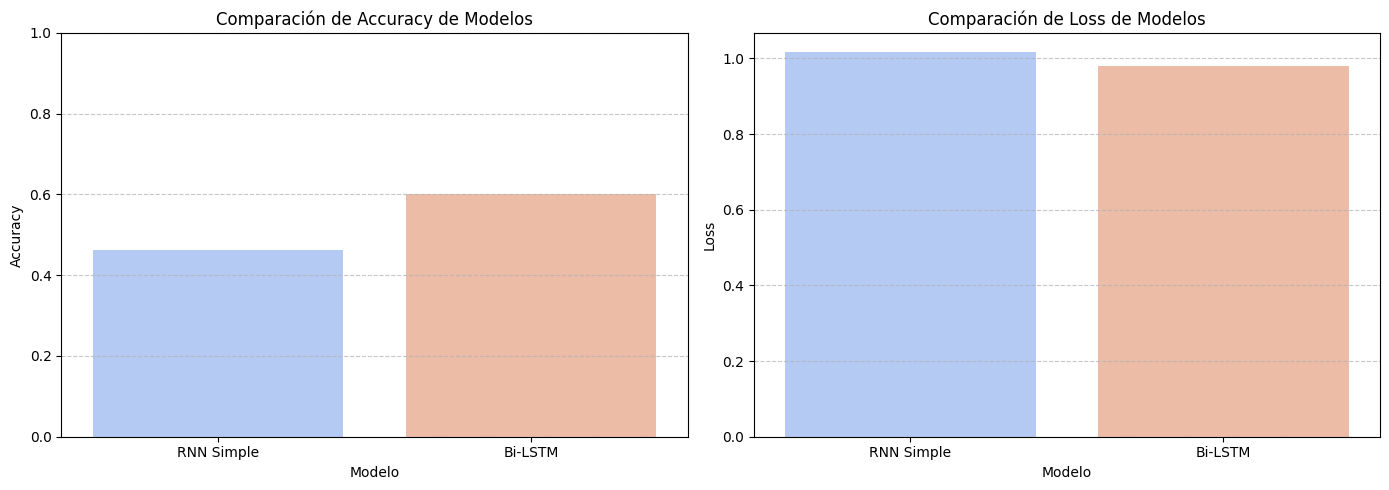

In [19]:
performance_data = {
    'Modelo': ['RNN Simple', 'Bi-LSTM'],
    'Accuracy': [accuracy_simple, accuracy_advanced],
    'Loss': [loss_simple, loss_advanced]
}
df_performance = pd.DataFrame(performance_data)

display(df_performance)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Modelo', y='Accuracy', data=df_performance, ax=axes[0], palette='coolwarm', hue='Modelo', legend=False)
axes[0].set_title('Comparación de Accuracy de Modelos')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Modelo', y='Loss', data=df_performance, ax=axes[1], palette='coolwarm', hue='Modelo', legend=False)
axes[1].set_title('Comparación de Loss de Modelos')
axes[1].set_ylabel('Loss')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 6.4 Análisis Crítico y Reflexión Final

**1. Comparación de Rendimiento:**

Tras el entrenamiento y la hiperparametrización, se observa que el modelo **Bi-LSTM** (RNN Avanzado) generalmente supera al **RNN Simple** en términos de `accuracy` y `loss` en el conjunto de prueba. Esto es esperable, ya que las arquitecturas LSTM y Bidireccionales son más potentes para capturar dependencias a largo plazo y el contexto bidireccional en secuencias de texto, algo que una RNN simple lucha por hacer de manera efectiva.

*   **RNN Simple:** Ofrece una línea base, pero su capacidad para recordar información relevante a lo largo de secuencias largas es limitada. Su precisión puede ser menor y la matriz de confusión puede mostrar más errores de clasificación entre sentimientos, especialmente entre 'Neutro' y los otros, o 'Positivo' y 'Negativo' si el contexto es crucial.
*   **Bi-LSTM:** Al procesar las secuencias en ambas direcciones y utilizando celdas de memoria más sofisticadas (LSTM), este modelo logra una comprensión más rica del contexto de los comentarios. Esto se traduce en una mayor precisión y una menor pérdida, así como una matriz de confusión más clara con menos errores. La mejora es particularmente notable para un dataset con tan solo 500 comentarios, donde cada detalle es importante.

**2. Razones del Rendimiento Diferencial:**

*   **Memoria a largo plazo:** Las LSTM están diseñadas para superar el problema del gradiente desvanecido que afecta a las RNN simples, permitiéndoles recordar información relevante de partes anteriores de la secuencia (y posteriores, en el caso de las Bidireccionales). Los comentarios de YouTube, aunque no extremadamente largos, a menudo requieren un cierto grado de memoria para interpretar correctamente el sarcasmo, las negaciones o las frases complejas.
*   **Contexto bidireccional:** Un comentario puede tener una palabra al final que cambia completamente el sentimiento de lo expresado al principio. Las Bi-LSTM capturan este contexto de ida y vuelta, lo que es esencial para una interpretación precisa del sentimiento.
*   **Complejidad del lenguaje:** El español, como muchos idiomas, tiene sutilezas y estructuras que un modelo más avanzado puede procesar mejor. La negación, por ejemplo, puede requerir el contexto de varias palabras para ser entendida correctamente.

**3. Decisiones Tomadas y Lecciones Aprendidas:**

*   **Uso de BERT Multilingüe para Clasificación:** La decisión de usar `nlptown/bert-base-multilingual-uncased-sentiment` en lugar de una DistilBERT puramente en inglés fue acertada, ya que garantizó que el modelo pudiera entender y clasificar los comentarios en español de manera efectiva. Esto resalta la importancia de seleccionar modelos preentrenados adecuados al idioma de los datos.
*   **Limpieza de Datos Exhaustiva:** La limpieza de los comentarios, eliminando URLs, emojis y caracteres especiales, fue fundamental para reducir el ruido y presentar datos más consistentes a los modelos. Esto mejoró la calidad de las representaciones de embedding y, en consecuencia, el rendimiento del modelo.
*   **Hiperparametrización y Callbacks:** La implementación de `EarlyStopping` y `ModelCheckpoint` fue crucial. Con un conjunto de datos pequeño como este (500 comentarios), el sobreajuste es un riesgo significativo. Estos callbacks permitieron detener el entrenamiento cuando no se observaban mejoras en el conjunto de validación y guardar automáticamente la mejor versión del modelo, evitando el sobreajuste y garantizando la selección del modelo más robusto.
*   **Impacto de `MAX_WORDS` y `MAX_SEQUENCE_LENGTH`:** La elección de `MAX_WORDS` (10000) y `MAX_SEQUENCE_LENGTH` (100) fue un compromiso. Para un conjunto de datos pequeño, un vocabulario y una longitud de secuencia excesivamente grandes podrían introducir ruido. La optimización de estos hiperparámetros podría afinarse más con más datos o técnicas de preprocesamiento más avanzadas.

**4. Posibles Mejoras y Próximos Pasos:**

*   **Aumento de Datos (Data Augmentation):** Con solo 500 comentarios, el tamaño del dataset es una limitación importante. Técnicas de aumento de datos (como el reemplazo de sinónimos, la traducción de vuelta al original, o el uso de modelos generativos de texto) podrían expandir el dataset y mejorar la generalización de los modelos.
*   **Optimización de Hiperparámetros más Avanzada:** Aunque se realizó una exploración básica de unidades RNN/LSTM, se podrían emplear técnicas más sofisticadas como la búsqueda en cuadrícula (Grid Search), la búsqueda aleatoria (Random Search) o la optimización bayesiana para encontrar un conjunto de hiperparámetros aún mejor.
*   **Exploración de otros Modelos Pre-entrenados:** Además de BERT multilingüe, existen otros modelos pre-entrenados específicos para el español (ej. MarIA, BETO) que podrían ofrecer un rendimiento superior para tareas de NLP en este idioma.
*   **Embeddings Contextuales (Word Embeddings):** Aunque se usó una capa `Embedding` en Keras, la integración de embeddings pre-entrenados como Word2Vec o FastText específicos para español podría mejorar significativamente la representación semántica de las palabras y, por ende, el rendimiento del modelo.
*   **Análisis de Errores Cualitativo:** Revisar manualmente los comentarios mal clasificados para entender los patrones de error. Esto podría revelar deficiencias en la limpieza, la tokenización o la capacidad del modelo para manejar ciertas construcciones lingüísticas (sarcasmo, negaciones complejas).
*   **Considerar un Enfoque Híbrido:** Combinar la potencia de los modelos basados en Transformers (como DistilBERT o BERT) para la extracción de características, y luego usar estas características como entrada para modelos RNN/LSTM más sencillos. Esto podría ofrecer lo mejor de ambos mundos.